# 🥇 Oro (XAU/USD) — Análisis Predictivo basado en Estructura de Mercado

Este notebook combina dos enfoques sobre el precio del oro (`PAXG-USD`, un token respaldado 1:1 por oro físico LBMA que sigue muy de cerca el spot XAU/USD real — ver sección 1 para el porqué):

1. **Forecast estadístico (Prophet)** sobre el precio diario — tendencia proyectada a `DIAS_FORECAST` días con banda de incertidumbre.
2. **Análisis de estructura de mercado (Smart Money Concepts)** — swings, quiebres de estructura (BOS), Order Blocks y su **tasa histórica de continuación**, en **1h** (estructura macro) y **15m** (entrada, confirmada contra 1h).
3. **Señal consolidada** — una zona operativa solo se marca como señal válida si la estructura, la probabilidad histórica **y** la tendencia proyectada por Prophet están alineadas.

### ⚠️ Aviso importante
El forecast de Prophet es una proyección estadística de tendencia, no una predicción de precio exacta. La "tasa de continuación" es un backtest simplificado sobre datos recientes. Herramienta educativa y analítica, **no asesoría financiera**.

## 1. Configuración

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from datetime import datetime
import yfinance as yf
import ta
from prophet import Prophet
from IPython.display import display, Markdown

# --- Símbolo ---
# PAXG-USD: PAX Gold, token cripto respaldado 1:1 por oro físico LBMA (yfinance).
# Se prefiere sobre "GC=F" (futuros COMEX): los futuros cotizan con una prima de
# contango/basis sobre el spot y su feed de Yahoo incluye horas de Globex poco
# líquidas con mechas ruidosas, por lo que su precio y estructura NO coinciden
# con lo que muestra un bróker de spot/CFD (p. ej. XAUUSD en TradingView/Capital.com).
# PAXG, al arbitrarse continuamente contra el oro físico, sigue el spot muy de cerca
# ("XAUUSD=X" ya no devuelve datos en yfinance). Contrapartida: PAXG cotiza 24/7
# (fines de semana incluidos), aunque con rango y volumen mucho menores esos días.
SYMBOL = "PAXG-USD"
SYMBOL_LABEL = "Oro (XAU/USD · proxy PAXG-USD)"

# --- Horizontes de datos ---
PERIODO_DIARIO = "2y"   # histórico para el forecast Prophet
PERIODO_1H = "180d"     # histórico para estructura macro (máx. permitido por yfinance: 730d)
PERIODO_15M = "60d"     # histórico para estructura de entrada (máx. permitido por yfinance: 60d)

# --- Forecast ---
DIAS_FORECAST = 30

# --- Estructura de mercado / Order Blocks ---
SWING_LOOKBACK = 3           # velas a cada lado para confirmar un swing high/low (fractal)
VENTANA_RESULTADO = 60       # velas máximas para juzgar si una zona "continuó" o "falló" tras ser testeada
N_ZONAS_SIMILARES = 40       # "últimas N zonas similares a la actual" usadas para la probabilidad
N_QUIEBRES_ESTRUCTURA = 20   # "últimos N quiebres de estructura" usados para la probabilidad
PESO_ZONAS = 0.6             # ponderación de la tasa por zonas similares en la probabilidad final
PESO_QUIEBRES = 0.4          # ponderación de la tasa por quiebres recientes
UMBRAL_PROBABILIDAD = 50.0   # % mínimo recomendado para considerar la zona
BANDA_NEUTRAL = (45, 55)     # % — dentro de esta banda se considera "neutral" y no se opera
SL_BUFFER_ATR = 0.15         # colchón del Stop Loss más allá del borde del Order Block, en múltiplos de ATR14

In [2]:
# Plaqueta fija con el ticker (y último precio) para todos los gráficos del notebook,
# estilo "ticker" de plataformas de trading: identifica el activo de un vistazo,
# sin depender de leer el título. Usa SYMBOL para no quedar desincronizada si
# se cambia el activo en la sección 1.
def agregar_placa_simbolo(ax, precio=None, loc="upper right"):
    x, ha = (0.98, "right") if "right" in loc else (0.02, "left")
    texto = SYMBOL if precio is None else f"{SYMBOL}\n{precio:,.2f} USD"
    ax.text(x, 0.98, texto, transform=ax.transAxes, ha=ha, va="top",
            fontsize=10, fontweight="bold", color="#1a1a1a", linespacing=1.6,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#d4af37", edgecolor="none", alpha=0.92))

## 2. Datos históricos del oro

In [3]:
def descargar_velas(symbol, period, interval):
    """Descarga velas OHLCV desde Yahoo Finance y normaliza las columnas."""
    df = yf.download(symbol, period=period, interval=interval, progress=False, auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.columns = [c.lower() for c in df.columns]
    df.index.name = "timestamp"
    return df[["open", "high", "low", "close", "volume"]].dropna()


df_diario = descargar_velas(SYMBOL, PERIODO_DIARIO, "1d")
df_1h = descargar_velas(SYMBOL, PERIODO_1H, "1h")
df_15m = descargar_velas(SYMBOL, PERIODO_15M, "15m")

print(f"✅ Diario: {len(df_diario)} velas, desde {df_diario.index[0].date()} hasta {df_diario.index[-1].date()}")
print(f"✅ 1h: {len(df_1h)} velas, desde {df_1h.index[0]} hasta {df_1h.index[-1]}")
print(f"✅ 15m: {len(df_15m)} velas, desde {df_15m.index[0]} hasta {df_15m.index[-1]}")

✅ Diario: 730 velas, desde 2024-08-17 hasta 2026-08-17
✅ 1h: 4294 velas, desde 2026-02-19 00:00:00+00:00 hasta 2026-08-17 01:00:00+00:00
✅ 15m: 5656 velas, desde 2026-06-19 00:00:00+00:00 hasta 2026-08-17 01:15:00+00:00


## 3. Forecast Prophet — precio diario del oro

Se entrena Prophet sobre el cierre diario y se proyectan `DIAS_FORECAST` días. La tendencia proyectada se clasifica con la **pendiente de una regresión lineal** sobre toda la cola del forecast (más robusto que comparar solo los dos últimos puntos, como en la versión original para ETH).

In [4]:
df_prophet = pd.DataFrame({
    "ds": pd.to_datetime(df_diario.index),
    "y": df_diario["close"].astype(float).values,
}).dropna()

modelo = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.5,
    interval_width=0.90,
)
modelo.fit(df_prophet)

futuro = modelo.make_future_dataframe(periods=DIAS_FORECAST)
forecast = modelo.predict(futuro)

# Tendencia proyectada: pendiente de una regresión lineal sobre los yhat de los
# próximos DIAS_FORECAST días (más robusta que comparar solo los últimos 2 puntos)
cola_forecast = forecast["yhat"].tail(DIAS_FORECAST).values
pendiente = np.polyfit(range(len(cola_forecast)), cola_forecast, 1)[0]
precio_actual = df_prophet["y"].iloc[-1]
variacion_pct = (cola_forecast[-1] / precio_actual - 1) * 100

if pendiente > 0 and variacion_pct > 1:
    tendencia_prophet = "alcista"
elif pendiente < 0 and variacion_pct < -1:
    tendencia_prophet = "bajista"
else:
    tendencia_prophet = "lateral"

print(f"Precio actual: {precio_actual:.2f}")
print(f"Proyección a {DIAS_FORECAST} días: {cola_forecast[-1]:.2f} ({variacion_pct:+.2f}%)")
print(f"Tendencia proyectada (Prophet): {tendencia_prophet.upper()}")

19:29:10 - cmdstanpy - INFO - Chain [1] start processing


19:29:11 - cmdstanpy - INFO - Chain [1] done processing


Precio actual: 4401.83
Proyección a 30 días: 5466.37 (+24.18%)
Tendencia proyectada (Prophet): ALCISTA


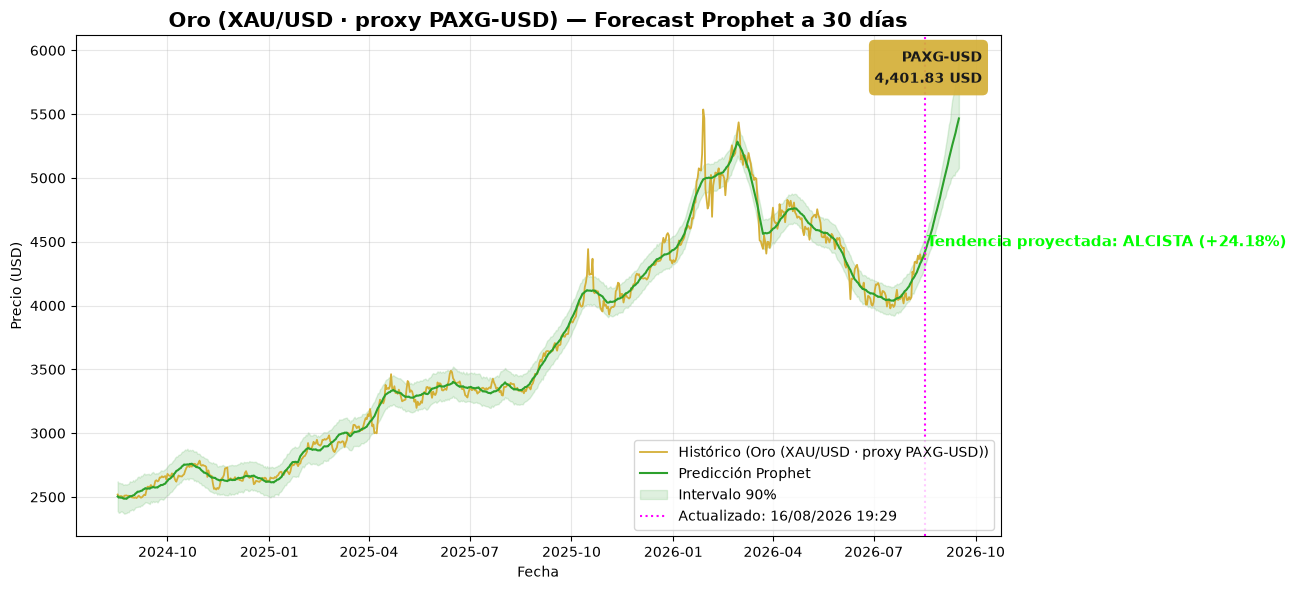

In [5]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(df_prophet["ds"], df_prophet["y"], color="#d4af37", linewidth=1.3, label=f"Histórico ({SYMBOL_LABEL})")
ax.plot(forecast["ds"], forecast["yhat"], color="#2ca02c", linewidth=1.5, label="Predicción Prophet")
ax.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"],
                color="#2ca02c", alpha=0.15, label=f"Intervalo {int(modelo.interval_width * 100)}%")

ahora = datetime.now()
ax.axvline(ahora, color="magenta", linestyle=":", linewidth=1.5,
           label=f"Actualizado: {ahora.strftime('%d/%m/%Y %H:%M')}")

color_tendencia = {"alcista": "lime", "bajista": "red", "lateral": "goldenrod"}[tendencia_prophet]
ax.text(forecast["ds"].iloc[-DIAS_FORECAST], forecast["yhat"].iloc[-DIAS_FORECAST],
        f"Tendencia proyectada: {tendencia_prophet.upper()} ({variacion_pct:+.2f}%)",
        color=color_tendencia, fontsize=11, fontweight="bold")

ax.set_title(f"{SYMBOL_LABEL} — Forecast Prophet a {DIAS_FORECAST} días", fontsize=15, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio (USD)")
agregar_placa_simbolo(ax, precio_actual)
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 4. Estructura de mercado (swings y quiebres de estructura)

Un **swing high/low** es un máximo/mínimo local confirmado por `SWING_LOOKBACK` velas a cada lado. Un **quiebre de estructura (BOS)** ocurre cuando el cierre supera el último swing high confirmado (quiebre alcista) o perfora el último swing low confirmado (quiebre bajista). El **Order Block** de ese quiebre es la última vela de color opuesto al movimiento impulsivo que lo originó.

Se detecta en dos temporalidades: **1h** (estructura macro) y **15m** (entrada, se valida contra la tendencia de 1h).

In [6]:
def detectar_swings(df, lookback=SWING_LOOKBACK):
    df = df.copy()
    ventana = 2 * lookback + 1
    roll_max = df["high"].rolling(ventana, center=True).max()
    roll_min = df["low"].rolling(ventana, center=True).min()
    df["swing_high"] = df["high"] == roll_max
    df["swing_low"] = df["low"] == roll_min
    return df


def detectar_estructura(df):
    """Recorre las velas cronológicamente y detecta quiebres de estructura (BOS) junto
    con el Order Block (última vela opuesta antes del impulso) que originó cada quiebre."""
    ultimo_sh = ultimo_sl = None
    quiebres = []
    tendencia = None

    idx_list = df.index
    highs, lows = df["high"].values, df["low"].values
    opens, closes = df["open"].values, df["close"].values
    sh_flags, sl_flags = df["swing_high"].values, df["swing_low"].values

    for i in range(len(df)):
        if sh_flags[i]:
            ultimo_sh = (i, highs[i])
        if sl_flags[i]:
            ultimo_sl = (i, lows[i])

        if ultimo_sh is not None and closes[i] > ultimo_sh[1] and i > ultimo_sh[0]:
            i_origen = ultimo_sl[0] if ultimo_sl is not None else max(0, ultimo_sh[0] - 1)
            idx_ob = next((j for j in range(i, i_origen - 1, -1) if closes[j] < opens[j]), None)
            if idx_ob is not None:
                quiebres.append({"idx_break": i, "tiempo_break": idx_list[i], "tipo": "alcista",
                                  "nivel_roto": ultimo_sh[1], "idx_ob": idx_ob, "tiempo_ob": idx_list[idx_ob],
                                  "zona_low": lows[idx_ob], "zona_high": highs[idx_ob]})
            ultimo_sh = None
            tendencia = "alcista"

        elif ultimo_sl is not None and closes[i] < ultimo_sl[1] and i > ultimo_sl[0]:
            i_origen = ultimo_sh[0] if ultimo_sh is not None else max(0, ultimo_sl[0] - 1)
            idx_ob = next((j for j in range(i, i_origen - 1, -1) if closes[j] > opens[j]), None)
            if idx_ob is not None:
                quiebres.append({"idx_break": i, "tiempo_break": idx_list[i], "tipo": "bajista",
                                  "nivel_roto": ultimo_sl[1], "idx_ob": idx_ob, "tiempo_ob": idx_list[idx_ob],
                                  "zona_low": lows[idx_ob], "zona_high": highs[idx_ob]})
            ultimo_sl = None
            tendencia = "bajista"

    return pd.DataFrame(quiebres), tendencia


df_1h = detectar_swings(df_1h)
df_15m = detectar_swings(df_15m)

quiebres_1h, tendencia_1h = detectar_estructura(df_1h)
quiebres_15m, tendencia_15m = detectar_estructura(df_15m)

print(f"1h: {len(quiebres_1h)} quiebres de estructura. Tendencia actual: {tendencia_1h}")
print(f"15m: {len(quiebres_15m)} quiebres de estructura. Tendencia actual: {tendencia_15m}")

1h: 189 quiebres de estructura. Tendencia actual: alcista
15m: 211 quiebres de estructura. Tendencia actual: alcista


## 5. Probabilidad histórica de continuación por zona

Para cada Order Block detectado se busca el primer regreso del precio a la zona `[zona_low, zona_high]` y, desde ahí, en una ventana de `VENTANA_RESULTADO` velas, se clasifica como `continuo` (alcanza el objetivo) o `fallo` (invalida la zona antes de alcanzarlo).

In [7]:
def evaluar_resultado_obs(df, obs, ventana_resultado=VENTANA_RESULTADO):
    highs, lows, closes = df["high"].values, df["low"].values, df["close"].values
    n = len(df)
    resultados = []

    for row in obs.itertuples():
        zona_low, zona_high = row.zona_low, row.zona_high
        altura = zona_high - zona_low
        if altura <= 0:
            resultados.append("sin_definir")
            continue

        if row.tipo == "alcista":
            objetivo, invalidacion = row.nivel_roto + altura, zona_low
        else:
            objetivo, invalidacion = row.nivel_roto - altura, zona_high

        idx_tap = None
        for j in range(row.idx_break + 1, min(n, row.idx_break + 1 + ventana_resultado * 3)):
            if lows[j] <= zona_high and highs[j] >= zona_low:
                idx_tap = j
                break
        if idx_tap is None:
            resultados.append("sin_toque")
            continue

        resultado = "sin_definir"
        for j in range(idx_tap, min(n, idx_tap + ventana_resultado)):
            if row.tipo == "alcista":
                if closes[j] <= invalidacion:
                    resultado = "fallo"; break
                if closes[j] >= objetivo:
                    resultado = "continuo"; break
            else:
                if closes[j] >= invalidacion:
                    resultado = "fallo"; break
                if closes[j] <= objetivo:
                    resultado = "continuo"; break
        resultados.append(resultado)

    obs = obs.copy()
    obs["resultado"] = resultados
    return obs


def tasa_continuacion(obs_resultado, n_ultimas, tipo=None):
    sub = obs_resultado if tipo is None else obs_resultado[obs_resultado["tipo"] == tipo]
    sub = sub[sub["resultado"].isin(["continuo", "fallo"])].tail(n_ultimas)
    if len(sub) == 0:
        return None, 0
    return round(100 * (sub["resultado"] == "continuo").mean(), 1), len(sub)

In [8]:
obs_resultado_1h = evaluar_resultado_obs(df_1h, quiebres_1h)
obs_resultado_15m = evaluar_resultado_obs(df_15m, quiebres_15m)

print("Resultados históricos — 1h:")
print(obs_resultado_1h["resultado"].value_counts())
print("\nResultados históricos — 15m:")
print(obs_resultado_15m["resultado"].value_counts())

Resultados históricos — 1h:
resultado
fallo          100
continuo        64
sin_toque       24
sin_definir      1
Name: count, dtype: int64

Resultados históricos — 15m:
resultado
fallo          115
continuo        63
sin_toque       28
sin_definir      5
Name: count, dtype: int64


## 6. Zona operativa consolidada (estructura + probabilidad + Prophet)

La señal se marca como **válida** solo si se cumplen a la vez:
- La zona está **alineada** con la tendencia de la temporalidad superior (15m se valida contra 1h; 1h no requiere confirmación).
- La **probabilidad histórica de continuación** supera `UMBRAL_PROBABILIDAD` y está fuera de la `BANDA_NEUTRAL`.
- La dirección de la zona coincide con la **tendencia proyectada por Prophet** (si Prophet está lateral, no descarta la señal).

**Stop Loss**: justo fuera del Order Block, con colchón `SL_BUFFER_ATR × ATR14`. **Take Profit**: el swing point opuesto más cercano no testeado (siguiente zona de liquidez).

In [9]:
def buscar_liquidez_objetivo(df_swings, tipo, precio_actual):
    if tipo == "alcista":
        candidatos = df_swings.loc[df_swings["swing_high"] & (df_swings["high"] > precio_actual), "high"]
        return candidatos.min() if not candidatos.empty else None
    else:
        candidatos = df_swings.loc[df_swings["swing_low"] & (df_swings["low"] < precio_actual), "low"]
        return candidatos.max() if not candidatos.empty else None


def evaluar_zona_operativa(quiebres, obs_resultado, df_estructura, atr_actual,
                            tendencia_confirmacion, tendencia_prophet, etiqueta_tf):
    zona_actual = quiebres.iloc[-1]
    tipo_zona = zona_actual["tipo"]

    tasa_zonas, n_zonas = tasa_continuacion(obs_resultado, N_ZONAS_SIMILARES, tipo=tipo_zona)
    tasa_quiebres, n_quiebres = tasa_continuacion(obs_resultado, N_QUIEBRES_ESTRUCTURA, tipo=None)

    if tasa_zonas is None:
        probabilidad = tasa_quiebres
    elif tasa_quiebres is None:
        probabilidad = tasa_zonas
    else:
        probabilidad = round(PESO_ZONAS * tasa_zonas + PESO_QUIEBRES * tasa_quiebres, 1)

    # tendencia_confirmacion=None -> 1h, no requiere confirmación de una TF superior
    alineado_estructura = tendencia_confirmacion is None or tendencia_confirmacion == tipo_zona
    alineado_prophet = tendencia_prophet == "lateral" or tendencia_prophet == tipo_zona
    en_banda_neutral = probabilidad is not None and BANDA_NEUTRAL[0] <= probabilidad <= BANDA_NEUTRAL[1]

    precio_actual = df_estructura["close"].iloc[-1]
    if tipo_zona == "alcista":
        entrada_sugerida = zona_actual["zona_high"]
        stop_loss = zona_actual["zona_low"] - SL_BUFFER_ATR * atr_actual
    else:
        entrada_sugerida = zona_actual["zona_low"]
        stop_loss = zona_actual["zona_high"] + SL_BUFFER_ATR * atr_actual

    take_profit = buscar_liquidez_objetivo(df_estructura, tipo_zona, precio_actual)
    riesgo = abs(entrada_sugerida - stop_loss)
    recompensa = abs(take_profit - entrada_sugerida) if take_profit is not None else None
    rr = round(recompensa / riesgo, 2) if recompensa else None

    señal_valida = (alineado_estructura and alineado_prophet and not en_banda_neutral and
                     probabilidad is not None and probabilidad > UMBRAL_PROBABILIDAD)

    return {
        "etiqueta_tf": etiqueta_tf, "zona_actual": zona_actual, "tipo_zona": tipo_zona,
        "probabilidad": probabilidad, "tasa_zonas": tasa_zonas, "n_zonas": n_zonas,
        "tasa_quiebres": tasa_quiebres, "n_quiebres": n_quiebres,
        "alineado_estructura": alineado_estructura, "alineado_prophet": alineado_prophet,
        "en_banda_neutral": en_banda_neutral, "precio_actual": precio_actual,
        "entrada": entrada_sugerida, "stop_loss": stop_loss, "take_profit": take_profit,
        "riesgo": riesgo, "rr": rr, "señal_valida": señal_valida,
    }

In [10]:
atr_1h = ta.volatility.AverageTrueRange(df_1h["high"], df_1h["low"], df_1h["close"], 14).average_true_range().iloc[-1]
atr_15m = ta.volatility.AverageTrueRange(df_15m["high"], df_15m["low"], df_15m["close"], 14).average_true_range().iloc[-1]

resultado_1h = evaluar_zona_operativa(quiebres_1h, obs_resultado_1h, df_1h, atr_1h,
                                       None, tendencia_prophet, "1h")
resultado_15m = evaluar_zona_operativa(quiebres_15m, obs_resultado_15m, df_15m, atr_15m,
                                        tendencia_1h, tendencia_prophet, "15m")

for r in (resultado_1h, resultado_15m):
    tp_txt = f"{r['take_profit']:.2f}" if r["take_profit"] is not None else "sin liquidez identificada"
    print(f"[{r['etiqueta_tf']}] zona {r['tipo_zona']} formada {r['zona_actual']['tiempo_ob']} — "
          f"rango [{r['zona_actual']['zona_low']:.2f}, {r['zona_actual']['zona_high']:.2f}]")
    print(f"   probabilidad continuación: {r['probabilidad']}% "
          f"(zonas similares n={r['n_zonas']} → {r['tasa_zonas']}% | quiebres n={r['n_quiebres']} → {r['tasa_quiebres']}%)")
    print(f"   alineado_estructura={r['alineado_estructura']} | alineado_prophet={r['alineado_prophet']} | "
          f"banda_neutral={r['en_banda_neutral']} | señal_valida={r['señal_valida']}")
    print(f"   entrada={r['entrada']:.2f} | SL={r['stop_loss']:.2f} | TP={tp_txt} | R:R≈1:{r['rr']}")
    print()

[1h] zona alcista formada 2026-08-16 20:00:00+00:00 — rango [4371.78, 4374.03]
   probabilidad continuación: 33.0% (zonas similares n=40 → 35.0% | quiebres n=20 → 30.0%)
   alineado_estructura=True | alineado_prophet=True | banda_neutral=False | señal_valida=False
   entrada=4374.03 | SL=4370.96 | TP=4411.25 | R:R≈1:12.13

[15m] zona alcista formada 2026-08-16 15:30:00+00:00 — rango [4371.36, 4372.20]
   probabilidad continuación: 43.5% (zonas similares n=40 → 42.5% | quiebres n=20 → 45.0%)
   alineado_estructura=True | alineado_prophet=True | banda_neutral=False | señal_valida=False
   entrada=4372.20 | SL=4370.75 | TP=4402.40 | R:R≈1:20.84



## 7. Señal final consolidada

In [11]:
def imprimir_señal_final(r):
    tp_txt = f"{r['take_profit']:.2f}" if r["take_profit"] is not None else "sin liquidez identificada"
    print("=" * 68)
    print(f"  ZONA DE ALTA PROBABILIDAD — {SYMBOL_LABEL}  [{r['etiqueta_tf']}]")
    print("=" * 68)
    print(f"Tipo de zona: {r['tipo_zona'].upper()}   |   Formada: {r['zona_actual']['tiempo_ob']}")
    print(f"Rango de la zona (Order Block): [{r['zona_actual']['zona_low']:.2f}, {r['zona_actual']['zona_high']:.2f}]")
    print(f"Probabilidad de continuación: {r['probabilidad']}%  (umbral recomendado: >{UMBRAL_PROBABILIDAD}%)")
    print(f"Tendencia proyectada Prophet a {DIAS_FORECAST}d: {tendencia_prophet.upper()} ({variacion_pct:+.2f}%)")
    print(f"Alineación con temporalidad superior: {'✅' if r['alineado_estructura'] else '❌'}   |   "
          f"Alineación con Prophet: {'✅' if r['alineado_prophet'] else '❌'}   |   "
          f"Fuera de banda neutral: {'✅' if not r['en_banda_neutral'] else '❌'}")
    print("-" * 68)
    if r["señal_valida"]:
        print(f"✅ SEÑAL VÁLIDA — {r['tipo_zona'].upper()}")
        print(f"   Entrada: {r['entrada']:.2f} | SL: {r['stop_loss']:.2f} | TP: {tp_txt} | R:R ≈ 1:{r['rr']}")
    else:
        motivos = []
        if not r["alineado_estructura"]:
            motivos.append("temporalidad superior no alineada")
        if not r["alineado_prophet"]:
            motivos.append("tendencia Prophet no alineada")
        if r["en_banda_neutral"]:
            motivos.append("probabilidad en banda neutral")
        if r["probabilidad"] is None or r["probabilidad"] <= UMBRAL_PROBABILIDAD:
            motivos.append("probabilidad por debajo del umbral")
        print(f"❌ NO OPERAR — motivo(s): {', '.join(motivos)}")
    print("=" * 68)
    print()


imprimir_señal_final(resultado_1h)
imprimir_señal_final(resultado_15m)

  ZONA DE ALTA PROBABILIDAD — Oro (XAU/USD · proxy PAXG-USD)  [1h]
Tipo de zona: ALCISTA   |   Formada: 2026-08-16 20:00:00+00:00
Rango de la zona (Order Block): [4371.78, 4374.03]
Probabilidad de continuación: 33.0%  (umbral recomendado: >50.0%)
Tendencia proyectada Prophet a 30d: ALCISTA (+24.18%)
Alineación con temporalidad superior: ✅   |   Alineación con Prophet: ✅   |   Fuera de banda neutral: ✅
--------------------------------------------------------------------
❌ NO OPERAR — motivo(s): probabilidad por debajo del umbral

  ZONA DE ALTA PROBABILIDAD — Oro (XAU/USD · proxy PAXG-USD)  [15m]
Tipo de zona: ALCISTA   |   Formada: 2026-08-16 15:30:00+00:00
Rango de la zona (Order Block): [4371.36, 4372.20]
Probabilidad de continuación: 43.5%  (umbral recomendado: >50.0%)
Tendencia proyectada Prophet a 30d: ALCISTA (+24.18%)
Alineación con temporalidad superior: ✅   |   Alineación con Prophet: ✅   |   Fuera de banda neutral: ✅
-----------------------------------------------------------

## 8. Visualización — velas y zona operativa

### 1h (estructura macro)

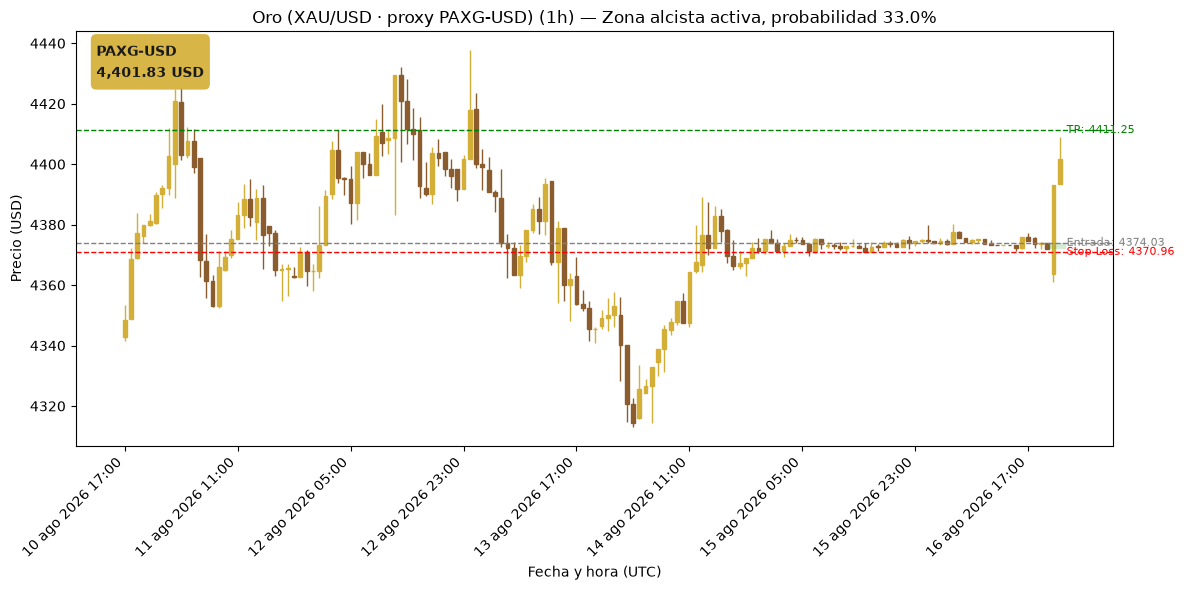

### 15m (entrada, confirmada contra 1h)

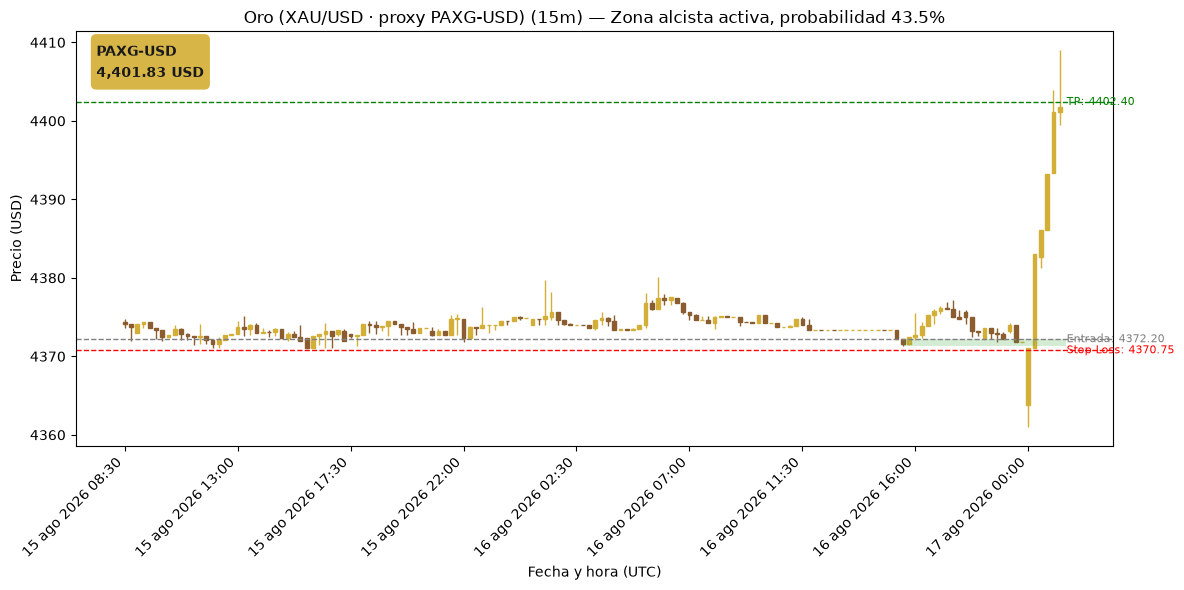

In [12]:
MESES_ES = {1: "ene", 2: "feb", 3: "mar", 4: "abr", 5: "may", 6: "jun",
            7: "jul", 8: "ago", 9: "sep", 10: "oct", 11: "nov", 12: "dic"}


def graficar_velas(ax, df, ancho=0.6, color_alcista="#d4af37", color_bajista="#8a5c2e"):
    x = np.arange(len(df))
    colores = np.where(df["close"].values >= df["open"].values, color_alcista, color_bajista)
    ax.vlines(x, df["low"].values, df["high"].values, color=colores, linewidth=1)
    cuerpo_bajo = np.minimum(df["open"].values, df["close"].values)
    cuerpo_alto = np.maximum(df["open"].values, df["close"].values) - cuerpo_bajo
    ax.bar(x, cuerpo_alto, bottom=cuerpo_bajo, width=ancho, color=colores, edgecolor=colores)
    return x


def formatear_eje_x(ax, indice_tiempo, n_ticks=8):
    """Etiquetas 'día mes año hora' (p. ej. '14 ago 2026 15:00') para evitar la
    ambigüedad del formato %m-%d ('08-14'), fácil de confundir con día-mes.
    El xlabel indica además la zona horaria de las velas."""
    n = len(indice_tiempo)
    paso = max(1, n // n_ticks)
    posiciones = list(range(0, n, paso))
    etiquetas = [
        f"{indice_tiempo[i].day:02d} {MESES_ES[indice_tiempo[i].month]} {indice_tiempo[i].year} "
        f"{indice_tiempo[i].strftime('%H:%M')}"
        for i in posiciones
    ]
    ax.set_xticks(posiciones)
    ax.set_xticklabels(etiquetas, rotation=45, ha="right")
    ax.set_xlabel(f"Fecha y hora ({indice_tiempo.tz})")


def graficar_zona_operativa(df, resultado, n_velas=150):
    df_plot = df.tail(n_velas)
    fig, ax = plt.subplots(figsize=(12, 6))
    x = graficar_velas(ax, df_plot)

    zona_actual = resultado["zona_actual"]
    pos_zona = df_plot.index.get_indexer([zona_actual["tiempo_ob"]])[0]
    if pos_zona == -1:
        pos_zona = 0  # la zona es más antigua que la ventana graficada
    color_zona = "tab:green" if resultado["tipo_zona"] == "alcista" else "tab:red"
    ax.add_patch(Rectangle((pos_zona, zona_actual["zona_low"]), len(df_plot) - pos_zona,
                            zona_actual["zona_high"] - zona_actual["zona_low"],
                            facecolor=color_zona, alpha=0.2, edgecolor="none"))

    for nivel, nombre, color in [(resultado["entrada"], "Entrada", "gray"),
                                  (resultado["stop_loss"], "Stop Loss", "red")]:
        ax.axhline(nivel, color=color, linestyle="--", linewidth=1)
        ax.annotate(f"{nombre}: {nivel:.2f}", xy=(x[-1], nivel), xytext=(5, 0),
                    textcoords="offset points", va="center", fontsize=8, color=color)
    if resultado["take_profit"] is not None:
        ax.axhline(resultado["take_profit"], color="green", linestyle="--", linewidth=1)
        ax.annotate(f"TP: {resultado['take_profit']:.2f}", xy=(x[-1], resultado["take_profit"]), xytext=(5, 0),
                    textcoords="offset points", va="center", fontsize=8, color="green")

    ax.set_title(f"{SYMBOL_LABEL} ({resultado['etiqueta_tf']}) — Zona {resultado['tipo_zona']} activa, "
                 f"probabilidad {resultado['probabilidad']}%")
    ax.set_ylabel("Precio (USD)")
    # Placa arriba a la izquierda: las etiquetas de Entrada/SL/TP viven en el borde
    # derecho (x[-1]), así que la esquina derecha queda reservada para ellas.
    agregar_placa_simbolo(ax, resultado["precio_actual"], loc="upper left")
    formatear_eje_x(ax, df_plot.index)
    fig.tight_layout()
    plt.show()


display(Markdown("### 1h (estructura macro)"))
graficar_zona_operativa(df_1h, resultado_1h)

display(Markdown("### 15m (entrada, confirmada contra 1h)"))
graficar_zona_operativa(df_15m, resultado_15m)

## 9. Exportar resumen a Excel (Power BI)

In [13]:
resumen_forecast = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df_prophet, on="ds", how="left"
).rename(columns={
    "ds": "Fecha", "y": "Historico", "yhat": "Prediccion_IA",
    "yhat_lower": "Margen_Inferior", "yhat_upper": "Margen_Superior",
})

resumen_senal = pd.DataFrame([{
    "Temporalidad": r["etiqueta_tf"],
    "Tipo_Zona": r["tipo_zona"],
    "Probabilidad_%": r["probabilidad"],
    "Entrada": r["entrada"],
    "Stop_Loss": r["stop_loss"],
    "Take_Profit": r["take_profit"],
    "R_R": r["rr"],
    "Senal_Valida": r["señal_valida"],
    "Tendencia_Prophet": tendencia_prophet,
} for r in (resultado_1h, resultado_15m)])

with pd.ExcelWriter("ORO_Predictivo.xlsx") as writer:
    resumen_forecast.to_excel(writer, sheet_name="Forecast_Prophet", index=False)
    resumen_senal.to_excel(writer, sheet_name="Senal_Estructura", index=False)

print("✅ Exportado a ORO_Predictivo.xlsx")
print(resumen_forecast.tail())

✅ Exportado a ORO_Predictivo.xlsx
         Fecha  Prediccion_IA  Margen_Inferior  Margen_Superior  Historico
755 2026-09-12    5324.446740      5017.423945      5701.118163        NaN
756 2026-09-13    5355.119403      5046.361209      5757.085757        NaN
757 2026-09-14    5394.954033      5050.663611      5811.116036        NaN
758 2026-09-15    5428.933392      5064.550366      5874.524035        NaN
759 2026-09-16    5466.365785      5078.051225      5939.223157        NaN


## 10. Estructura proyectada para la semana de trading (calendario económico)

Se proyecta la **semana cubierta por el calendario económico** (`calendario_economico_ftmo/economic_calendar.xlsx`), combinando:

- El **precio reciente** (velas 1h) para ver la estructura vigente.
- El **forecast Prophet** (banda de incertidumbre) para los días de esa semana.
- Los **niveles activos** de la última zona operativa en 1h (Order Block, SL, TP) de la sección 6.
- Los **eventos económicos relevantes para USD/XAU** de la semana (afectan directamente al oro, cotizado en USD), marcados por nivel de restricción/impacto de FTMO: `0=bajo`, `1=medio`, `2=alto` → mayor probabilidad de volatilidad o quiebre de estructura alrededor de esas horas.

No se incluyen eventos de otras divisas (CAD, GBP, etc.) que no mencionen USD/XAUUSD explícitamente, ya que no son catalizadores directos del precio del oro.

In [14]:
RUTA_CALENDARIO = "calendario_economico_ftmo/economic_calendar.xlsx"

def cargar_calendario_economico(ruta, zona_horaria):
    """Carga el calendario económico FTMO y normaliza fechas a la zona horaria dada."""
    cal = pd.read_excel(ruta)
    cal["Fechas"] = pd.to_datetime(cal["Fechas"]).dt.tz_convert(zona_horaria)
    return cal.sort_values("Fechas").reset_index(drop=True)


calendario = cargar_calendario_economico(RUTA_CALENDARIO, df_1h.index.tz)

# Eventos relevantes para el oro: instrumento USD (mueve el DXY) o que mencionen XAUUSD explícitamente
es_relevante_oro = calendario["Instrumento"].str.contains("USD|XAU", case=False, na=False)
calendario_oro = calendario.loc[es_relevante_oro].copy()

IMPACTO_LABEL = {0: "Bajo", 1: "Medio", 2: "Alto"}
IMPACTO_COLOR = {0: "gray", 1: "orange", 2: "red"}
calendario_oro["Impacto"] = calendario_oro["Restricciones"].map(IMPACTO_LABEL)

inicio_semana = calendario_oro["Fechas"].min().normalize()
fin_semana = calendario_oro["Fechas"].max().normalize()

print(f"Semana cubierta por el calendario: {inicio_semana.date()} → {fin_semana.date()}")
print(f"Eventos relevantes para XAU/USD: {len(calendario_oro)}")
display(calendario_oro[["Fechas", "Descripción", "Instrumento", "Impacto", "Pronóstico", "Previo"]]
        .reset_index(drop=True))

Semana cubierta por el calendario: 2026-08-17 → 2026-08-21
Eventos relevantes para XAU/USD: 17


,Fechas,Descripción,Instrumento,Impacto,Pronóstico,Previo
0,2026-08-17 12:30:00+00:00,Empire State Manufacturing Index,USD,Bajo,10.6,15.6
1,2026-08-17 14:00:00+00:00,NAHB Housing Market Index,USD,Bajo,33,34
2,2026-08-17 20:00:00+00:00,TIC Long-Term Purchases,USD,Bajo,151.4 B,232.7 B
3,2026-08-18 12:15:00+00:00,ADP Weekly Employment Change,USD,Bajo,Sin pronóstico,8.3 K
4,2026-08-18 12:30:00+00:00,Building Permits,USD,Bajo,1.37 M,1.37 M
5,2026-08-18 12:30:00+00:00,Housing Starts,USD,Bajo,1.35 M,1.43 M
6,2026-08-18 12:30:00+00:00,Import Prices m/m,USD,Bajo,0.1 %,0.3 %
7,2026-08-18 13:15:00+00:00,Industrial Production m/m,USD,Bajo,0.3 %,0.1 %
8,2026-08-18 13:15:00+00:00,Capacity Utilization Rate,USD,Bajo,76.3 %,76.1 %
9,2026-08-18 14:00:00+00:00,Pending Home Sales m/m,USD,Bajo,0.1 %,-5.4 %


In [15]:
resumen_dias = (calendario_oro.assign(Dia=calendario_oro["Fechas"].dt.date)
                 .groupby("Dia")["Impacto"].value_counts().unstack(fill_value=0))
for col in ["Bajo", "Medio", "Alto"]:
    if col not in resumen_dias.columns:
        resumen_dias[col] = 0
resumen_dias = resumen_dias[["Bajo", "Medio", "Alto"]]

print("Densidad de eventos USD/XAU por día de la semana:\n")
print(resumen_dias)
print()
for dia, row in resumen_dias.iterrows():
    if row["Alto"] > 0:
        etiqueta = "🔴 alta probabilidad de volatilidad / quiebre de estructura"
    elif row["Medio"] > 0:
        etiqueta = "🟠 volatilidad moderada esperada"
    elif row["Bajo"] > 0:
        etiqueta = "⚪ solo eventos de bajo impacto"
    else:
        etiqueta = "— sin eventos relevantes"
    print(f"{dia} ({pd.Timestamp(dia).day_name()}): {etiqueta}")

Densidad de eventos USD/XAU por día de la semana:

Impacto     Bajo  Medio  Alto
Dia                          
2026-08-17     3      0     0
2026-08-18     8      0     0
2026-08-19     0      1     0
2026-08-20     3      0     0
2026-08-21     2      0     0

2026-08-17 (Monday): ⚪ solo eventos de bajo impacto
2026-08-18 (Tuesday): ⚪ solo eventos de bajo impacto
2026-08-19 (Wednesday): 🟠 volatilidad moderada esperada
2026-08-20 (Thursday): ⚪ solo eventos de bajo impacto
2026-08-21 (Friday): ⚪ solo eventos de bajo impacto


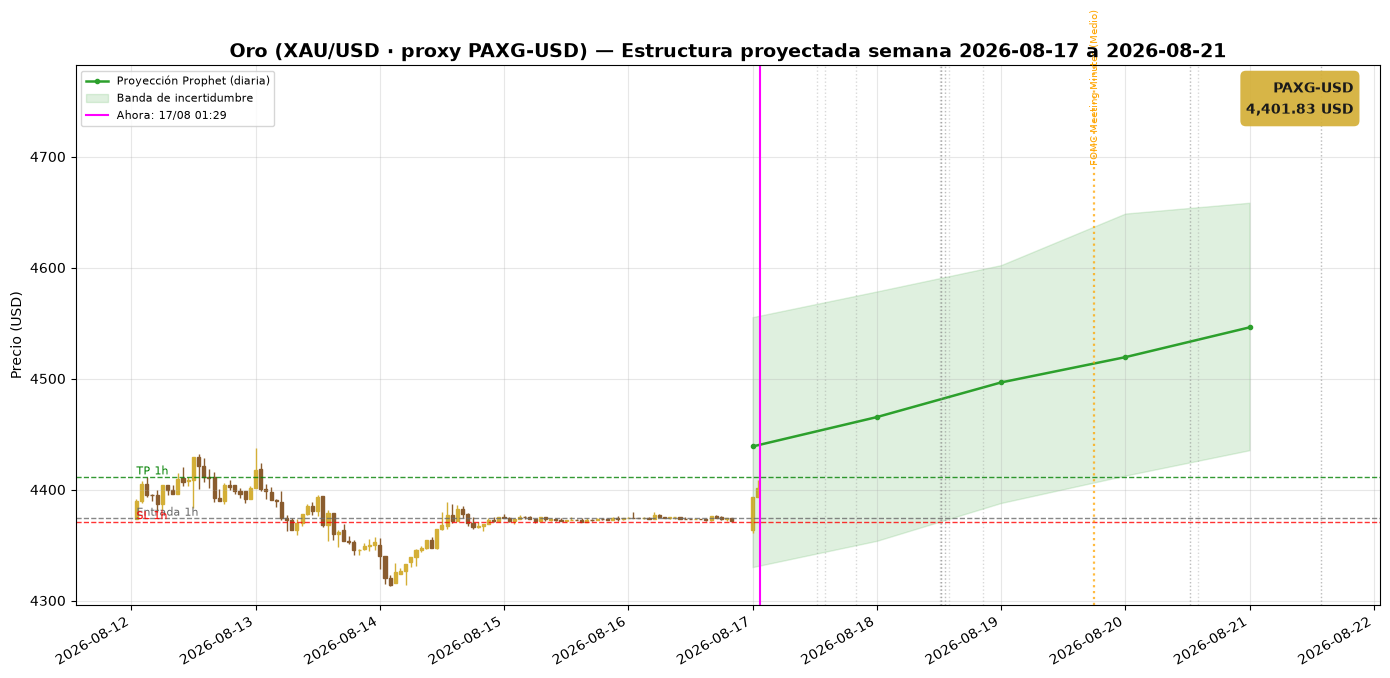

In [16]:
def graficar_velas_temporales(ax, df, color_alcista="#d4af37", color_bajista="#8a5c2e"):
    """Igual que graficar_velas, pero sobre un eje x de fechas reales (no posiciones enteras),
    para poder compartir el eje con el forecast Prophet y los eventos del calendario."""
    paso_dias = (df.index[1] - df.index[0]).total_seconds() / 86400 if len(df) > 1 else 1 / 24
    ancho = paso_dias * 0.6
    colores = np.where(df["close"].values >= df["open"].values, color_alcista, color_bajista)
    ax.vlines(df.index, df["low"].values, df["high"].values, color=colores, linewidth=1)
    cuerpo_bajo = np.minimum(df["open"].values, df["close"].values)
    cuerpo_alto = np.maximum(df["open"].values, df["close"].values) - cuerpo_bajo
    ax.bar(df.index, cuerpo_alto, bottom=cuerpo_bajo, width=ancho, color=colores, edgecolor=colores)


# Precio reciente (últimos 5 días de velas 1h) para dar contexto de estructura hasta "ahora"
velas_recientes = df_1h[df_1h.index >= (df_1h.index[-1] - pd.Timedelta(days=5))]

# Forecast Prophet acotado a la semana del calendario económico
forecast_semana = forecast[(forecast["ds"] >= inicio_semana.tz_localize(None)) &
                            (forecast["ds"] <= fin_semana.tz_localize(None))].copy()
forecast_semana["ds"] = forecast_semana["ds"].dt.tz_localize(df_1h.index.tz)

fig, ax = plt.subplots(figsize=(14, 7))
graficar_velas_temporales(ax, velas_recientes)

ax.plot(forecast_semana["ds"], forecast_semana["yhat"], color="#2ca02c", linewidth=1.8,
        marker="o", markersize=3, label="Proyección Prophet (diaria)")
ax.fill_between(forecast_semana["ds"], forecast_semana["yhat_lower"], forecast_semana["yhat_upper"],
                color="#2ca02c", alpha=0.15, label="Banda de incertidumbre")

# Última zona operativa activa en 1h, como referencia de estructura vigente
for nivel, nombre, color in [(resultado_1h["entrada"], "Entrada 1h", "dimgray"),
                              (resultado_1h["stop_loss"], "SL 1h", "red")]:
    ax.axhline(nivel, color=color, linestyle="--", linewidth=1, alpha=0.8)
    ax.annotate(nombre, xy=(velas_recientes.index[0], nivel), fontsize=8, color=color, va="bottom")
if resultado_1h["take_profit"] is not None:
    ax.axhline(resultado_1h["take_profit"], color="green", linestyle="--", linewidth=1, alpha=0.8)
    ax.annotate("TP 1h", xy=(velas_recientes.index[0], resultado_1h["take_profit"]),
                fontsize=8, color="green", va="bottom")

# Dejar margen arriba para las etiquetas verticales de los eventos económicos
ylim_bajo, ylim_alto = ax.get_ylim()
margen = (ylim_alto - ylim_bajo) * 0.28
ax.set_ylim(ylim_bajo, ylim_alto + margen)
y_texto = ylim_alto + margen * 0.15

for _, ev in calendario_oro.iterrows():
    color = IMPACTO_COLOR[ev["Restricciones"]]
    ax.axvline(ev["Fechas"], color=color, linestyle=":",
               linewidth=1.6 if ev["Restricciones"] else 1,
               alpha=0.75 if ev["Restricciones"] else 0.3)
    if ev["Restricciones"] >= 1:
        ax.annotate(f"{ev['Descripción']} ({ev['Impacto']})", xy=(ev["Fechas"], y_texto), rotation=90,
                    fontsize=7, color=color, ha="center", va="bottom", clip_on=False)

ahora = datetime.now(df_1h.index.tz)
ax.axvline(ahora, color="magenta", linestyle="-", linewidth=1.5,
           label=f"Ahora: {ahora.strftime('%d/%m %H:%M')}")

ax.set_title(f"{SYMBOL_LABEL} — Estructura proyectada semana {inicio_semana.date()} a "
             f"{fin_semana.date()}", fontsize=14, fontweight="bold")
ax.set_ylabel("Precio (USD)")
agregar_placa_simbolo(ax, velas_recientes["close"].iloc[-1])
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()